# RouteScout — Router mechanism validation

Phase 8A asks one engineering question:

> Can the pinned KiCad PNS / PCBWorld setup execute the **same within-net routine** under deliberately
> different net-selection orders?

This is a control/mechanism test, not a routing-performance claim.

The notebook starts from the frozen evidence so it is useful on an ordinary laptop. A full Linux
router rebuild is optional and documented at the end.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "results").exists() and (ROOT.parent / "results").exists():
    ROOT = ROOT.parent

runs = pd.read_csv(ROOT / "results" / "phase8a_pilot_runs_frozen.csv")
summary = json.loads(
    (ROOT / "results" / "phase8a_runner_summary_frozen.json").read_text()
)

summary


{'boards_scanned': 32,
 'eligible_boards': 3,
 'runs': 18,
 'api_error_runs': 0,
 'order_mismatch_runs': 0}

## Frozen execution checks

The frozen Phase 8A release contains **18 runs** on **3 eligible pilot boards**:

- three policies: natural, MST-hard-first, MST-easy-first;
- two repeats per board/policy;
- zero API errors;
- zero requested-vs-realized order mismatches.

No policy-performance threshold was used.


In [2]:
checks = {
    "eligible_boards": summary["eligible_boards"],
    "runs": summary["runs"],
    "api_error_runs": summary["api_error_runs"],
    "order_mismatch_runs": summary["order_mismatch_runs"],
    "all_orders_exact": bool(runs["order_exact"].astype(bool).all()),
}
checks


{'eligible_boards': 3,
 'runs': 18,
 'api_error_runs': 0,
 'order_mismatch_runs': 0,
 'all_orders_exact': True}

![Phase 8A feasibility gate](../figures/phase8a_feasibility_gate.svg)

The gate only validates experimental control. It does **not** claim that one order routes better.


## Descriptive policy diagnostics

Runtime, DRC count and reward are diagnostics only. Phase 8A is not allowed to select a winning
policy from these values.


In [3]:
diagnostics = (
    runs.groupby("policy", as_index=False)
    .agg(
        runs=("policy", "size"),
        mean_drc_count=("drc_count", "mean"),
        mean_elapsed_seconds=("elapsed_seconds", "mean"),
        mean_reward=("reward_total", "mean"),
    )
)
diagnostics


,policy,runs,mean_drc_count,mean_elapsed_seconds,mean_reward
0,mst_easy_first,6,3.333333,0.068945,8.035067
1,mst_hard_first,6,3.333333,0.068713,7.989325
2,natural,6,3.333333,0.070162,8.043896


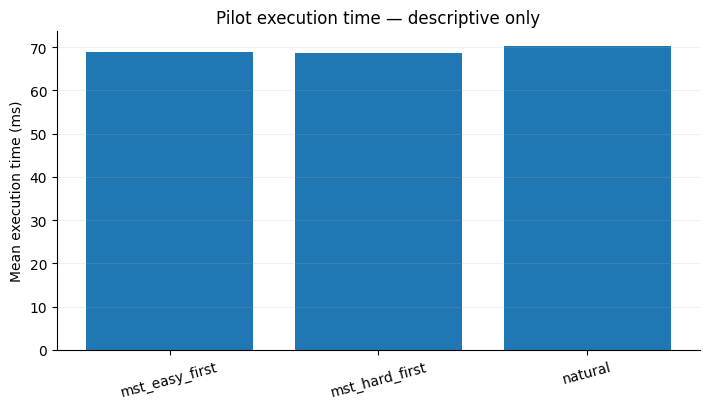

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(
    diagnostics["policy"],
    diagnostics["mean_elapsed_seconds"] * 1000,
)
ax.set_ylabel("Mean execution time (ms)")
ax.set_title("Pilot execution time — descriptive only")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.18)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Optional full mechanism rerun

A full rerun is **not required** to review the repository.

It requires the pinned Linux/Colab KiCad toolchain:

```bash
python scripts/bootstrap_phase8a.py --root .work/phase8a
```

Then run the clean Phase 8A runner against the prepared pilot boards. The reviewed clean runner is
locked in this repository at:

`07e2b0968e3af398b1b231d8ed724faf07af2c54a15bcee5b2a20bb8c4c39782`

The canonical Phase 8A release identity is documented in
`docs/reproducibility_frozen.md`.
